In [1]:
import numpy as np
from scipy.stats import norm

from engin_core.gp import fit_gp, split_conformal_multiplier
from engin_core.simulator import simulate_unit

GAUSS_90 = norm.ppf(0.95)   # ±1.645 sd, the textbook 90% Gaussian interval
NOMINAL = 0.90

def campaign(seed, n=120, d=5):
    """A space-filling DoE with heteroscedastic observation noise."""
    rng = np.random.default_rng(seed)
    U = rng.random((n, d))
    y_true = simulate_unit(U)
    y_obs = np.maximum(y_true + rng.normal(0, 0.05 * y_true + 0.4), 0.0)
    return U, y_obs

In [2]:
def coverages(seeds):
    epistemic, gaussian, conformal = [], [], []
    for seed in seeds:
        U, y = campaign(seed)
        tr, ca, te = slice(0, 70), slice(70, 100), slice(100, 120)
        gp = fit_gp(U[tr], y[tr], seed=seed)

        # calibration split -> one multiplier, from residuals the model never saw
        mc, sdc = gp.predict(U[ca], include_noise=True)
        q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)

        m_noise, sd_noise = gp.predict(U[te], include_noise=True)
        m_epi,   sd_epi   = gp.predict(U[te], include_noise=False)
        err_noise = np.abs(m_noise - y[te])
        err_epi   = np.abs(m_epi - y[te])

        epistemic.append(np.mean(err_epi   <= GAUSS_90 * sd_epi))
        gaussian.append( np.mean(err_noise <= GAUSS_90 * sd_noise))
        conformal.append(np.mean(err_noise <= q * sd_noise))
    return epistemic, gaussian, conformal

seeds = range(6)
epistemic, gaussian, conformal = coverages(seeds)

for name, cov in (
    ("epistemic-only Gaussian", epistemic),
    ("Gaussian, noise included", gaussian),
    ("split conformal", conformal),
):
    print(f"  {name:26s} {np.mean(cov):.3f}   (nominal {NOMINAL})")

/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


  epistemic-only Gaussian    0.583   (nominal 0.9)
  Gaussian, noise included   0.900   (nominal 0.9)
  split conformal            0.958   (nominal 0.9)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


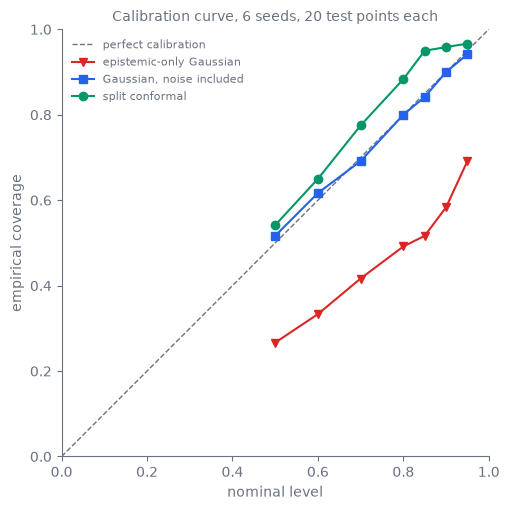

In [3]:
import matplotlib.pyplot as plt

LEVELS = np.array([0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95])

def coverage_curves(seeds):
    """Empirical coverage at each nominal level, averaged over seeds.

    One GP fit per seed, reused across levels -- the fit does not depend on the
    level, only the multiplier does. `warn_below_slack=None` silences the
    small-calibration-set warning per level; the size question is the subject of
    its own section below rather than something to repeat seven times here.
    """
    out = {k: [] for k in ("epistemic", "gaussian", "conformal")}
    for seed in seeds:
        U, y = campaign(seed)
        tr, ca, te = slice(0, 70), slice(70, 100), slice(100, 120)
        gp = fit_gp(U[tr], y[tr], seed=seed)
        mc, sdc = gp.predict(U[ca], include_noise=True)
        m_noise, sd_noise = gp.predict(U[te], include_noise=True)
        m_epi, sd_epi = gp.predict(U[te], include_noise=False)
        err_noise, err_epi = np.abs(m_noise - y[te]), np.abs(m_epi - y[te])
        z = norm.ppf(0.5 + LEVELS / 2)
        out["epistemic"].append([np.mean(err_epi <= zi * sd_epi) for zi in z])
        out["gaussian"].append([np.mean(err_noise <= zi * sd_noise) for zi in z])
        out["conformal"].append([
            np.mean(err_noise <= split_conformal_multiplier(
                y[ca], mc, sdc, level=L, warn_below_slack=None) * sd_noise)
            for L in LEVELS
        ])
    return {k: np.mean(v, axis=0) for k, v in out.items()}

curves = coverage_curves(range(6))

# Neutral grey and transparent background so the figure reads on the light and
# dark site themes alike; axes pinned to the full [0,1] probability range rather
# than auto-scaled, which is the axis choice that would flatter this most.
GREY = "#6b7280"
fig, ax = plt.subplots(figsize=(5.2, 5.2))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.plot([0, 1], [0, 1], color=GREY, ls="--", lw=1, label="perfect calibration", zorder=1)
for key, label, colour, marker in (
    ("epistemic", "epistemic-only Gaussian", "#dc2626", "v"),
    ("gaussian", "Gaussian, noise included", "#2563eb", "s"),
    ("conformal", "split conformal", "#059669", "o"),
):
    ax.plot(LEVELS, curves[key], marker=marker, color=colour, label=label, zorder=2)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_xlabel("nominal level"); ax.set_ylabel("empirical coverage")
ax.set_title("Calibration curve, 6 seeds, 20 test points each", fontsize=10, color=GREY)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(GREY)
ax.tick_params(colors=GREY)
ax.xaxis.label.set_color(GREY); ax.yaxis.label.set_color(GREY)
ax.legend(fontsize=8, loc="upper left", frameon=False, labelcolor=GREY)
fig.tight_layout()

In [4]:
U, y = campaign(0)
tr, ca = slice(0, 70), slice(70, 100)
gp = fit_gp(U[tr], y[tr], seed=0)
mc, sdc = gp.predict(U[ca], include_noise=True)
q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)

print(f"  Gaussian multiplier : {GAUSS_90:.3f}")
print(f"  conformal multiplier: {q:.3f}")
print(f"  intervals are {q / GAUSS_90:.2f}x wider than the Gaussian interval")

  Gaussian multiplier : 1.645
  conformal multiplier: 1.960
  intervals are 1.19x wider than the Gaussian interval


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/83446308.py:5: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


In [5]:
from engin_core import conformal_coverage_interval, smallest_calibration_set

print(f"  floor for a {NOMINAL:.0%} interval: n = {smallest_calibration_set(NOMINAL)}\n")
for n in (9, 20, 30, 50, 100, 406, 1000):
    lo, mean, hi = conformal_coverage_interval(n, level=NOMINAL)
    print(f"  n = {n:>4}   coverage {lo:.3f} to {hi:.3f}   (mean {mean:.3f})")

  floor for a 90% interval: n = 9

  n =    9   coverage 0.717 to 0.994   (mean 0.900)
  n =   20   coverage 0.784 to 0.982   (mean 0.905)
  n =   30   coverage 0.805 to 0.972   (mean 0.903)
  n =   50   coverage 0.826 to 0.960   (mean 0.902)
  n =  100   coverage 0.848 to 0.945   (mean 0.901)
  n =  406   coverage 0.876 to 0.925   (mean 0.902)
  n = 1000   coverage 0.884 to 0.915   (mean 0.900)


In [6]:
for label, s in (("6 seeds", range(6)), ("12 seeds", range(12))):
    epi, _, conf = coverages(s)
    print(f"  {label:9s} epistemic-only {np.mean(epi):.3f}   split conformal {np.mean(conf):.3f}")

/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


...

/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


  12 seeds  epistemic-only 0.558   split conformal 0.962


/var/folders/vk/d66475g5429_fzym5tpk90g40000gn/T/ipykernel_56577/815839376.py:10: UserWarning: calibration set of 30 gives a 90% interval whose true coverage lies in roughly [0.80, 0.97] (central 90%, Beta(n+1-l, l)). The multiplier is honest on average and noisy here. Pass `warn_below_slack=None` to silence, or see `conformal_coverage_interval` for the size you need.
  q = split_conformal_multiplier(y[ca], mc, sdc, level=NOMINAL)


In [7]:
from engin_core.gp import mapie_split_interval

te = slice(100, 120)
lo, hi = mapie_split_interval(gp, U[ca], y[ca], U[te], level=NOMINAL)
covered = np.mean((y[te] >= lo) & (y[te] <= hi))
_, sd_te = gp.predict(U[te], include_noise=True)
widths = hi - lo
print(f"  MAPIE constant-width coverage: {covered:.3f}")
print(f"  width, narrowest to widest:    {widths.min():.3f} to {widths.max():.3f} g/L")
print(f"  sd-normalized, for comparison: {(2 * q * sd_te).min():.3f} to {(2 * q * sd_te).max():.3f} g/L")

  MAPIE constant-width coverage: 0.950
  width, narrowest to widest:    15.551 to 15.551 g/L
  sd-normalized, for comparison: 14.782 to 20.816 g/L
